---
title: 'Wykład 6: Sieci konwolucyjne'
subtitle: Biblioteki Python w analizie danych
author: Tomasz Rodak
jupyter: python3
---


## Motywacja

Sieci konwolucyjne (CNN — *convolutional neural networks*) rozwiązują dwa problemy, które pojawiają się, gdy próbujemy przetwarzać obrazy za pomocą klasycznej sieci MLP z wykładu 5:

1. liczba parametrów eksploduje wraz z rozmiarem obrazu,
2. brak niezmienniczości ze względu na przesunięcia.

### Liczba parametrów

Pojedynczy neuron w pierwszej warstwie ukrytej MLP ma postać

\begin{equation*}
z = f(\mathbf{w}^T \mathbf{x} + b),
\end{equation*}

gdzie $\mathbf{w}$ to wektor wag o tej samej długości co wejście $\mathbf{x}$, $b$ to bias, a $f$ to funkcja aktywacji. Dla obrazu o rozmiarze $1000 \times 1000$ pikseli w trzech kanałach kolorów wejście ma długość $3 \cdot 10^6$, więc pojedynczy neuron ma $3\cdot 10^6 + 1$ parametrów. Warstwa z tysiącem neuronów ma już rzędu $3 \cdot 10^9$ parametrów — zanim w ogóle dotkniemy kolejnych warstw.

Dla obrazu MNIST $28 \times 28$ liczby są skromniejsze, ale logika ta sama: każdy neuron pierwszej warstwy musi mieć wagę dla każdego piksela. Każda waga jest niezależna od innych.

### Brak niezmienniczości translacyjnej

MLP patrzy na obraz globalnie. Każdy piksel ma swoją osobną wagę, więc obraz z czarną cyfrą „1" w lewym górnym rogu i ten sam obraz po przesunięciu cyfry w prawy dolny róg są dla sieci dwoma zupełnie różnymi wejściami. Aby nauczyć ją, że obie wersje reprezentują tę samą klasę, musimy pokazać przykłady „1" we wszystkich możliwych położeniach. Tymczasem nasz mózg radzi sobie z tym bez najmniejszego problemu: cyfra to cyfra niezależnie od tego, gdzie się znajduje.

Sieci konwolucyjne adresują oba problemy jedną ideą: **filtra przesuwającego się po obrazie z dzielonymi wagami**.

## Filtry konwolucyjne

Wyobraźmy sobie prostokątne **okno** (*receptive field*) — najczęściej kwadrat $3 \times 3$ lub $5 \times 5$ — które przesuwa się po obrazie, w każdym położeniu obejmując mały fragment pikseli. W obrębie okna stosujemy operację

\begin{equation*}
z = \mathbf{w}^T \mathbf{x} + b,
\end{equation*}

gdzie $\mathbf{x}$ to spłaszczony wektor pikseli wewnątrz okna, a $\mathbf{w}$ i $b$ to **wagi filtra** (kernela) — wspólne dla wszystkich położeń okna. Tablicę uzyskaną przez zastosowanie filtra $\mathbf{K}$ do wszystkich położeń w obrazie $\mathbf{I}$ nazywamy **konwolucją** i oznaczamy $\mathbf{I} \ast \mathbf{K}$.

Dla filtra o rozmiarze $h \times w$ formalnie:

\begin{equation*}
[\mathbf{I} \ast \mathbf{K}](i, j) = \sum_{m=0}^{h-1} \sum_{n=0}^{w-1} \mathbf{I}(i + m, j + n) \cdot \mathbf{K}(m, n).
\end{equation*}

**Uwaga terminologiczna.** W ścisłej matematyce konwolucja zawiera odwrócenie jądra (sumujemy $\mathbf{I}(i - m, j - n) \cdot \mathbf{K}(m, n)$). Operacja zdefiniowana powyżej to formalnie *korelacja krzyżowa*. W deep learningu konsekwentnie używa się korelacji krzyżowej, a nazywa się ją konwolucją — wagi filtra i tak są uczone, więc operacyjnie nie ma różnicy.

### Przykład rachunkowy

Niech

\begin{equation*}
\mathbf{I} = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{bmatrix}, \quad
\mathbf{K} = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}.
\end{equation*}

Filtr $2 \times 2$ mieści się w obrazie $3 \times 3$ na cztery sposoby, więc wynik konwolucji ma rozmiar $2 \times 2$:

\begin{equation*}
\mathbf{I} \ast \mathbf{K} = \begin{bmatrix}
1\cdot 1 + 2\cdot 2 + 4\cdot 3 + 5\cdot 4 & 2\cdot 1 + 3\cdot 2 + 5\cdot 3 + 6\cdot 4 \\
4\cdot 1 + 5\cdot 2 + 7\cdot 3 + 8\cdot 4 & 5\cdot 1 + 6\cdot 2 + 8\cdot 3 + 9\cdot 4
\end{bmatrix} = \begin{bmatrix} 37 & 47 \\ 67 & 77 \end{bmatrix}.
\end{equation*}

### Filtr to detektor cechy lokalnej

Na wyjściu z warstwy konwolucyjnej znajduje się funkcja aktywacji, najczęściej ReLU, stosowana elementwise:

\begin{equation*}
z = \text{ReLU}(\mathbf{w}^T \mathbf{x} + b).
\end{equation*}

Pojedyncza aktywacja $z$ „widzi" tylko tę część obrazu, która znajduje się w jej oknie. Wagi filtra są jednak współdzielone między wszystkimi położeniami okna, więc w każdym z nich liczona jest ta sama operacja. Ponieważ $\mathbf{w}^T \mathbf{x}$ to iloczyn skalarny, przyjmuje największe wartości tam, gdzie wektor pikseli $\mathbf{x}$ jest „kierunkowo zgodny" z wagami filtra. ReLU wygasza wszystkie aktywacje mniejsze od $-b$ i przepuszcza pozostałe. W efekcie filtr działa jak **detektor lokalnej cechy** — wzorca, który najlepiej dopasowuje się do jego wag.

Filtr $3 \times 3$ ma tylko 10 parametrów (9 wag + bias), niezależnie od rozmiaru obrazu, do którego go stosujemy. To kluczowa zmiana w stosunku do MLP.

#### Przykład: detekcja krawędzi

Pokażmy działanie konwolucji na konkretnym obrazie. Skorzystamy z wbudowanego zdjęcia `camera` z biblioteki `scikit-image` (512×512, skala szarości).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from skimage.data import camera

arr = camera()                              # tablica numpy uint8, kształt (512, 512)
arr = arr.astype(np.float32) / 255.0        # normalizacja do [0, 1]
img_tensor = torch.tensor(arr).unsqueeze(0).unsqueeze(0)  # kształt (1, 1, 512, 512)
img_tensor.shape

torch.Size([1, 1, 512, 512])

PyTorch oczekuje tensorów obrazowych w kształcie `(batch, channels, height, width)`. Dla pojedynczego obrazu w skali szarości dodajemy więc dwa wymiary jednostkowe: kanał i batch. Dla obrazów RGB wymiar `channels` byłby równy 3.

Definiujemy dwa filtry — pionowy i poziomy — odpowiadające detektorom krawędzi:

\begin{equation*}
\mathbf{K}_{\text{v}} = \begin{bmatrix} 1 & 0 & -1 \\ 1 & 0 & -1 \\ 1 & 0 & -1 \end{bmatrix}, \quad
\mathbf{K}_{\text{h}} = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix}.
\end{equation*}

In [2]:
vertical_filter = torch.tensor(
    [[1, 0, -1],
     [1, 0, -1],
     [1, 0, -1]], dtype=torch.float32
).unsqueeze(0).unsqueeze(0)              # kształt (1, 1, 3, 3) dla conv2d

horizontal_filter = torch.transpose(vertical_filter, 2, 3)

Wykonujemy konwolucję obrazu z każdym z filtrów. Argument `padding=1` dodaje warstwę zer wokół obrazu, dzięki czemu wynik zachowuje oryginalny rozmiar $512 \times 512$ (do paddingu wrócimy w następnej sekcji).

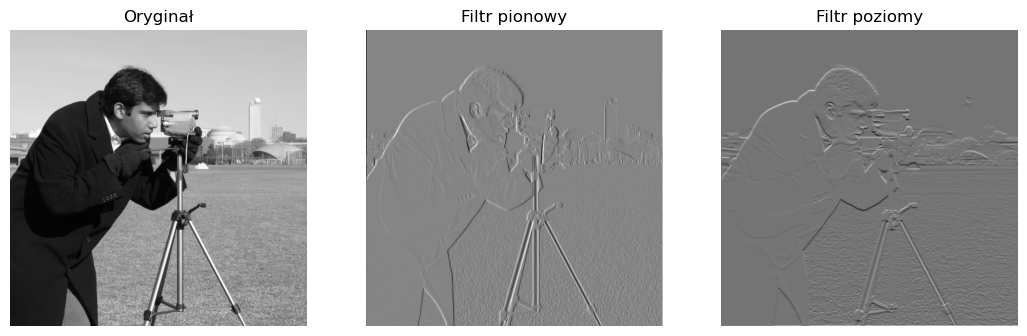

In [3]:
def apply_filter(img, kernel):
    """Konwolucja + normalizacja wyniku do [0, 1] dla wizualizacji."""
    out = nn.functional.conv2d(img, kernel, padding=1)
    out = out.squeeze().numpy()
    out = (out - out.min()) / (out.max() - out.min())
    return out

img_vertical = apply_filter(img_tensor, vertical_filter)
img_horizontal = apply_filter(img_tensor, horizontal_filter)

fig, axs = plt.subplots(1, 3, figsize=(13, 5))
axs[0].imshow(arr, cmap="gray");          axs[0].set_title("Oryginał")
axs[1].imshow(img_vertical, cmap="gray"); axs[1].set_title("Filtr pionowy")
axs[2].imshow(img_horizontal, cmap="gray"); axs[2].set_title("Filtr poziomy")
for ax in axs: ax.axis("off");

Filtr pionowy daje silne odpowiedzi tam, gdzie obraz ma pionowe krawędzie (przejścia jasność-ciemność wzdłuż osi poziomej), a filtr poziomy — tam, gdzie krawędzie są poziome. W obu przypadkach jeden filtr o dziewięciu wagach wyłapał konkretną cechę geometryczną *w całym obrazie* — bez konieczności uczenia osobnych wag dla każdego położenia. To jest właśnie współdzielenie wag w praktyce.

## Padding

Konwolucja obrazu o wymiarach $H \times W$ filtrem o wymiarach $h \times w$ daje wyjście o rozmiarze

\begin{equation*}
H_{\text{out}} = H - h + 1, \quad W_{\text{out}} = W - w + 1,
\end{equation*}

czyli obraz nieznacznie się kurczy. Przy wielu kolejnych warstwach konwolucyjnych obraz mógłby zniknąć — i tracilibyśmy informację o pikselach przy brzegach (które trafiają tylko do nielicznych okien).

**Padding** (dopełnianie) polega na otoczeniu obrazu warstwą sztucznych pikseli przed konwolucją. Dodanie $p$ pikseli z każdej strony daje obraz o wymiarach $(H + 2p) \times (W + 2p)$, a po konwolucji:

\begin{equation*}
H_{\text{out}} = H + 2p - h + 1, \quad W_{\text{out}} = W + 2p - w + 1.
\end{equation*}

Dla filtra $3 \times 3$ wystarczy $p = 1$, żeby zachować oryginalny rozmiar; dla filtra $5 \times 5$ — $p = 2$. Dodatkowe piksele zazwyczaj wypełnia się zerami (*zero-padding*); jeśli wcześniej od obrazu odjęto średnią, to zero jest wartością neutralną.

## Stride

**Stride** $s$ to krok, o jaki przesuwamy okno filtra. Wartość domyślna $s = 1$ oznacza, że filtr przesuwa się o jeden piksel; większy stride redukuje rozmiar wyjścia i jest jedną z technik downsamplingu. Ogólny wzór na rozmiar wyjścia:

\begin{equation*}
H_{\text{out}} = \left\lfloor \frac{H + 2p - h}{s} \right\rfloor + 1, \quad
W_{\text{out}} = \left\lfloor \frac{W + 2p - w}{s} \right\rfloor + 1.
\end{equation*}

## Konwolucje z wieloma kanałami i filtrami

Do tej pory rozważaliśmy obraz w skali szarości — jeden kanał. Dla obrazów kolorowych mamy $C$ kanałów wejściowych (np. RGB ma $C = 3$). Filtr konwolucyjny dla $C$ kanałów ma wymiary $h \times w \times C$ i $hwC$ wag plus jeden bias — wszystkie kanały są przetwarzane razem przez jeden filtr.

Aby sieć mogła wykrywać różnorodne cechy lokalne, filtry organizuje się w **tensor filtrów** o wymiarach $h \times w \times C \times C_{\text{out}}$, gdzie $C_{\text{out}}$ to liczba filtrów w danej warstwie. Każdy filtr produkuje jedną **mapę aktywacji**, więc wyjście warstwy konwolucyjnej ma $C_{\text{out}}$ kanałów.

Łączna liczba parametrów warstwy konwolucyjnej wynosi $(hwC + 1) \cdot C_{\text{out}}$. Dla typowych wartości ($h = w = 3$, $C = 3$, $C_{\text{out}} = 64$) daje to $(28) \cdot 64 = 1792$ parametry — w porównaniu do milionów, których wymagałaby gęsto połączona warstwa o tej samej funkcjonalności.

**Kluczowa zaleta**: liczba parametrów warstwy konwolucyjnej nie zależy od rozmiaru obrazu $H \times W$. Tę samą warstwę można zastosować do obrazu MNIST ($28 \times 28$) i do zdjęcia w wysokiej rozdzielczości.

## Pooling

Pooling to operacja redukcji rozmiaru obrazu *bez parametrów do uczenia*. Podobnie jak w konwolucji, przesuwamy po obrazie prostokątne okno, ale zamiast obliczać iloczyn skalarny z wagami, agregujemy piksele okna prostą funkcją — najczęściej maksimum (**max pooling**) lub średnią (**average pooling**). Krok przesuwania okna zwykle równa się jego rozmiarowi, więc okna nie nakładają się.

Pooling stosowany jest do każdego kanału z osobna — zmniejsza wysokość i szerokość, ale zachowuje liczbę kanałów. Typowy max pooling $2 \times 2$ ze stride $2$ zmniejsza obraz dwukrotnie w każdym wymiarze, a wymiar kanałowy pozostaje bez zmian.

## Equiwariantność i niezmienniczość

Sieci konwolucyjne są lokalnie **ekwiwariantne względem przesunięcia**: jeśli przesuniemy obraz wejściowy, to odpowiadające mu mapy aktywacji również przesuną się w przybliżeniu o tę samą wartość. Wynika to ze współdzielenia wag — ten sam filtr jest stosowany w różnych położeniach obrazu, więc ta sama cecha może zostać wykryta niezależnie od miejsca wystąpienia. W praktyce dokładna ekwiwariantność może być zaburzona przez padding, brzegi obrazu, stride i pooling.

Pooling wprowadza natomiast **lokalną, przybliżoną niezmienniczość** względem małych przesunięć. Na przykład max-pooling może dać tę samą odpowiedź, jeśli cecha przesunie się wewnątrz tego samego okna poolingowego i nadal pozostanie wartością maksymalną. Po kilku warstwach receptywne pola neuronów rosną, a reprezentacja staje się mniej wrażliwa na dokładne położenie lokalnych cech.


## Pole recepcyjne

W jednowarstwowej konwolucji pojedyncza aktywacja zależy od kwadratu $h \times w$ pikseli wejścia. Co się dzieje, gdy ułożymy kilka warstw konwolucyjnych jedna na drugiej?

**Pole recepcyjne** (*receptive field*, RF) aktywacji w warstwie $l$ to zbiór pikseli *oryginalnego wejścia*, od których ta aktywacja zależy. Im głębsza warstwa, tym większe pole recepcyjne — i tym większy fragment obrazu „widzi" pojedynczy neuron.

### Wzór rekurencyjny

Niech $r_l$ oznacza rozmiar pola recepcyjnego po warstwie $l$ (liczony w pikselach wejścia), a $j_l$ — **skok** (*jump*), czyli odległość między sąsiednimi pikselami wejścia, na które „patrzą" sąsiednie aktywacje w warstwie $l$. Dla warstwy o rozmiarze jądra $k_l$ i stride $s_l$:

\begin{equation*}
r_l = r_{l-1} + (k_l - 1) \cdot j_{l-1}, \qquad j_l = j_{l-1} \cdot s_l,
\end{equation*}

z warunkami początkowymi $r_0 = 1$, $j_0 = 1$ (pojedynczy piksel wejścia, sąsiednie piksele odległe o 1).

**Intuicja.** Sąsiednie aktywacje warstwy $l$ widzą fragmenty wejścia odległe o $j_{l-1}$ pikseli. Filtr o rozmiarze $k_l$ obejmuje $k_l$ takich aktywacji, więc rozciągnięcie pola recepcyjnego rośnie o $(k_l - 1) \cdot j_{l-1}$. Każdy stride > 1 (najczęściej pochodzący z poolingu) zwiększa skok, więc każda kolejna konwolucja „widzi" dwukrotnie szerszy fragment wejścia.

### Tabela dla LeNet-5

Backbone konwolucyjny LeNet-5 (do której wrócimy za chwilę) składa się z czterech warstw: dwie pary konwolucja–pooling. Policzmy pole recepcyjne na końcu części konwolucyjnej:

| Warstwa | $k$ | $s$ | $r$ przed | $j$ przed | $r$ po | $j$ po |
|---|---|---|---|---|---|---|
| wejście | — | — | — | — | 1 | 1 |
| conv1 | 5 | 1 | 1 | 1 | 5 | 1 |
| pool1 | 2 | 2 | 5 | 1 | 6 | 2 |
| conv2 | 5 | 1 | 6 | 2 | 14 | 2 |
| pool2 | 2 | 2 | 14 | 2 | 16 | 4 |

Pojedyncza aktywacja na wyjściu części konwolucyjnej LeNet-5 widzi okno $16 \times 16$ na wejściu $28 \times 28$ — czyli *nieco ponad połowę* obrazu w każdym wymiarze. Pojedyncza aktywacja nie widzi całej cyfry; pełną integrację cech zapewniają dopiero warstwy w pełni połączone, które są nad częścią konwolucyjną.

Dla większych obrazów (ImageNet $224 \times 224$) potrzeba znacznie głębszych sieci, żeby pole recepcyjne pokryło sensowny fragment wejścia. To jeden z argumentów za architekturami takimi jak ResNet, które omówimy w wykładzie 7.

## Architektura sieci konwolucyjnej

Typowy „klocek" prostej sieci konwolucyjnej składa się z trzech warstw:

1. konwolucja,
2. aktywacja (zwykle ReLU),
3. pooling (zwykle max pooling).

Sieć składa kilka takich klocków jeden na drugim — z każdą kolejną parą konwolucja-pooling rozmiar przestrzenny obrazu maleje, liczba kanałów rośnie, a pole recepcyjne się powiększa.

Na końcu części konwolucyjnej stosuje się **warstwę spłaszczającą** (*flatten*), która przekształca mapy aktywacji o kształcie $C_{\text{out}} \times H' \times W'$ w wektor o długości $C_{\text{out}} \cdot H' \cdot W'$. Wektor ten trafia do klasycznej sieci MLP, która produkuje finalne wyjście (logity klas w przypadku klasyfikacji).

## LeNet-5

[LeNet-5](http://en.wikipedia.org/wiki/LeNet-5) to jedna z pierwszych sieci konwolucyjnych — zaprojektowana przez Yanna LeCuna i jego współpracowników w 1998 roku do rozpoznawania cyfr w obrazach $28 \times 28$ pikseli. Mimo że ma już ponad ćwierć wieku, pozostaje doskonałym przykładem podstawowej architektury CNN — wystarczająco prostym, by zmieścić ją w głowie w całości, i wystarczająco silnym, by osiągnąć przyzwoity wynik na MNIST.

### Architektura

LeNet-5 składa się z dwóch par konwolucja–pooling, po których następuje trójwarstwowy MLP:

| Warstwa | Wejście | Operacja | Wyjście |
|---|---|---|---|
| `conv1` | $1 \times 28 \times 28$ | Conv 5×5, pad=2 | $6 \times 28 \times 28$ |
| `pool` | $6 \times 28 \times 28$ | MaxPool 2×2, stride=2 | $6 \times 14 \times 14$ |
| `conv2` | $6 \times 14 \times 14$ | Conv 5×5, pad=0 | $16 \times 10 \times 10$ |
| `pool` | $16 \times 10 \times 10$ | MaxPool 2×2, stride=2 | $16 \times 5 \times 5$ |
| `flatten` | $16 \times 5 \times 5$ | — | $400$ |
| `fc1` | $400$ | Linear | $120$ |
| `fc2` | $120$ | Linear | $84$ |
| `fc3` | $84$ | Linear | $10$ |

Liczba $16 \cdot 5 \cdot 5 = 400$ wejść do `fc1` bierze się wprost z arytmetyki kształtów: po dwóch parach konwolucja–pooling z mapy o rozmiarze przestrzennym $28 \times 28$ zostaje $5 \times 5$, ale liczba kanałów wzrasta z 1 do 16.

Pole recepcyjne na końcu części konwolucyjnej (po `pool2`) wynosi $16 \times 16$ — jak policzyliśmy w poprzedniej sekcji.

### Wczytanie danych

In [4]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.MNIST(
    root="data", train=True, download=True, transform=ToTensor(),
)
test_data = datasets.MNIST(
    root="data", train=False, download=True, transform=ToTensor(),
)

train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,     batch_size=64, shuffle=False)

Podgląd kilku przykładowych obrazków:

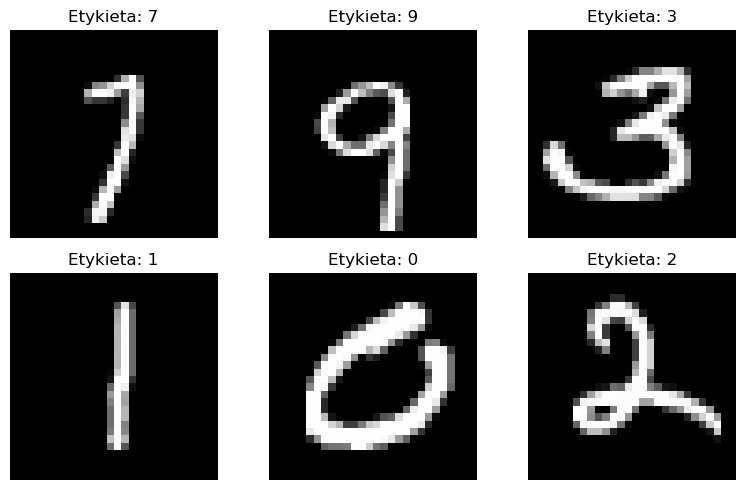

In [5]:
import matplotlib.pyplot as plt

idx = np.random.randint(0, len(training_data), 6)
fig, axs = plt.subplots(2, 3, figsize=(8, 5))
for i, ax in enumerate(axs.flat):
    img, label = training_data[idx[i]]
    ax.imshow(img[0], cmap="gray")
    ax.set_title(f"Etykieta: {label}")
    ax.axis("off")
plt.tight_layout();

### Implementacja

In [6]:
class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.act = nn.ReLU()
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.act(self.conv1(x))         # --> 6 x 28 x 28
        x = self.pool(x)                    # --> 6 x 14 x 14
        x = self.act(self.conv2(x))         # --> 16 x 10 x 10
        x = self.pool(x)                    # --> 16 x 5 x 5
        x = torch.flatten(x, 1)             # --> 400
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)                     # logity, 10 klas
        return x

**Uwaga historyczna.** Oryginalna sieć LeCuna z 1998 roku używała funkcji aktywacji `tanh` (oraz wyspecjalizowanego, ręcznie zaprojektowanego mechanizmu łączenia kanałów między `conv1` a `conv2`). Tutaj zastępujemy `tanh` przez ReLU jako współczesny standard — różnica w wynikach na MNIST jest niewielka, ale ReLU znacznie lepiej skaluje się dla głębszych sieci. Decyzję tę zobaczymy w pełnej skali w wykładzie 7, gdy zajmiemy się pretrenowanymi sieciami z ReLU-podobnymi aktywacjami.

### GPU jako naturalne środowisko CNN-ów

Konwolucja sprowadza się do ogromnej liczby niezależnych mnożeń i akumulacji (MAC — *multiply-accumulate*): dla każdego położenia okna, każdego kanału wejściowego i każdego filtra wykonujemy jedno mnożenie i jedną sumę. Te operacje są **wzajemnie niezależne** — żadna nie czeka na wynik innej — więc idealnie nadają się do zrównoleglenia. Procesor (CPU) ma kilkanaście rdzeni, karta graficzna (GPU) tysiące. Dlatego praktyczne trenowanie sieci konwolucyjnych odbywa się na GPU.

PyTorch udostępnia spójny interfejs do urządzeń obliczeniowych. Standardowy idiom:

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Trening na: {device}")

Trening na: cpu


Aby skorzystać z GPU, trzeba przenieść na nie **dwa rodzaje obiektów**: model (z jego parametrami) i dane wejściowe. Modele przenosimy raz, zaraz po utworzeniu; dane — w każdej iteracji pętli treningowej, ponieważ `DataLoader` ładuje je do RAM-u CPU.

In [8]:
model = LeNet5().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

W praktycznych zastosowaniach (Colab z kartą T4, lokalna stacja z GPU) ten sam kod uruchomi się na GPU, jeśli jest dostępne — w przeciwnym razie spadnie na CPU. Dla LeNet-5 na MNIST różnica nie jest dramatyczna; dla głębszych sieci na ImageNet to różnica między godziną a tygodniem treningu.

### Pętla treningowa z ewaluacją per epoka

W wykładzie 5 pisaliśmy pętlę treningową dla `make_moons`. Tutaj rozszerzamy ją o ewaluację na zbiorze testowym po każdej epoce, żeby śledzić, czy sieć generalizuje.

In [9]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X)
        n += len(X)
    return total_loss / n


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            total_loss += loss_fn(pred, y).item() * len(X)
            total_correct += (pred.argmax(dim=1) == y).sum().item()
            n += len(X)
    return total_loss / n, total_correct / n


n_epochs = 5
hist_train_loss, hist_test_loss, hist_test_acc = [], [], []

for epoch in range(1, n_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    hist_train_loss.append(train_loss)
    hist_test_loss.append(test_loss)
    hist_test_acc.append(test_acc)
    print(f"Epoka {epoch}: train_loss = {train_loss:.4f}, "
          f"test_loss = {test_loss:.4f}, test_acc = {test_acc:.4f}")

Epoka 1: train_loss = 0.2846, test_loss = 0.0932, test_acc = 0.9694
Epoka 2: train_loss = 0.0822, test_loss = 0.0603, test_acc = 0.9811
Epoka 3: train_loss = 0.0581, test_loss = 0.0440, test_acc = 0.9851
Epoka 4: train_loss = 0.0453, test_loss = 0.0451, test_acc = 0.9849
Epoka 5: train_loss = 0.0377, test_loss = 0.0357, test_acc = 0.9881


Krzywe uczenia — strata i dokładność w jednym wykresie obok siebie:

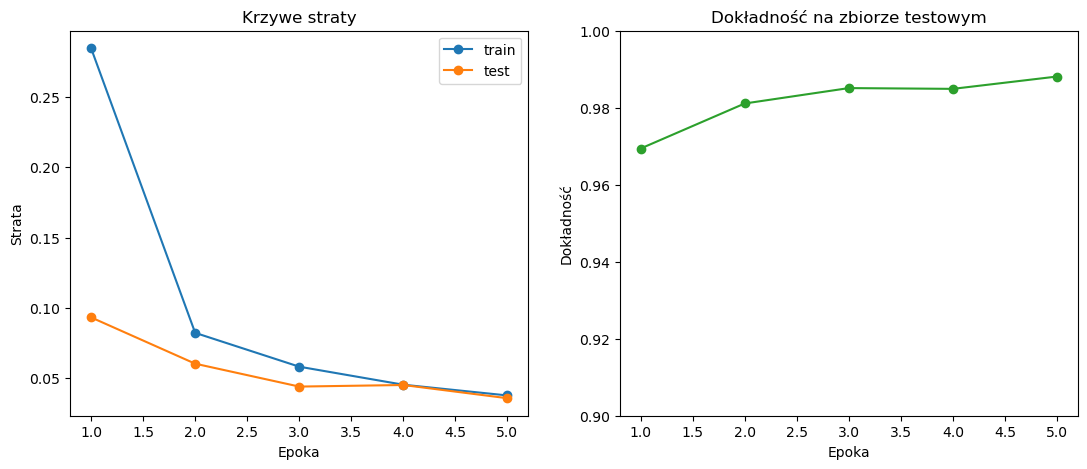

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, n_epochs + 1), hist_train_loss, label="train", marker="o")
axes[0].plot(range(1, n_epochs + 1), hist_test_loss,  label="test",  marker="o")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Strata")
axes[0].set_title("Krzywe straty"); axes[0].legend()

axes[1].plot(range(1, n_epochs + 1), hist_test_acc, marker="o", color="C2")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Dokładność")
axes[1].set_title("Dokładność na zbiorze testowym")
axes[1].set_ylim(0.9, 1.0);

Po pięciu epokach sieć osiąga dokładność rzędu 98–99% na zbiorze testowym MNIST. Strata treningowa konsekwentnie maleje; strata testowa również, ale wolniej — to typowy sygnał, że sieć stopniowo dopasowuje się do zbioru treningowego. Przy dłuższym treningu zaczęłaby się przeuczać.

### Diagnostyka

Macierz pomyłek pokazuje, które cyfry sieć myli ze sobą:

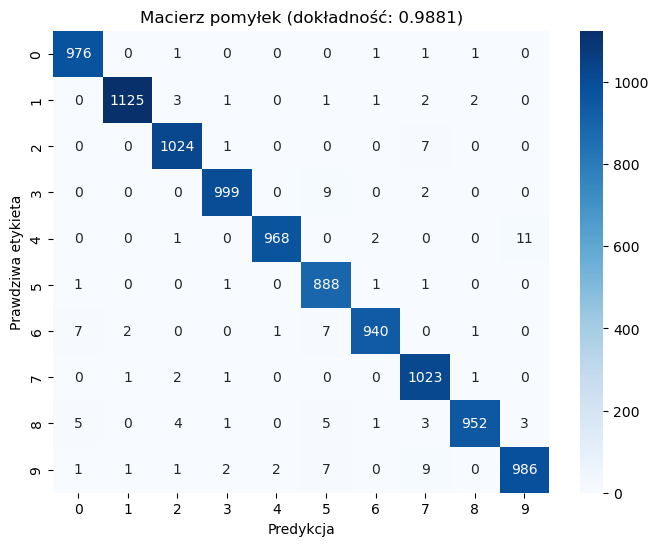

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X).argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(pred)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predykcja"); ax.set_ylabel("Prawdziwa etykieta")
ax.set_title(f"Macierz pomyłek (dokładność: {acc:.4f})");

Większość błędów to zwykle mylenie cyfr o podobnym kształcie: 4↔9, 3↔5, 7↔1. Przyjrzyjmy się sześciu losowym błędnym klasyfikacjom:

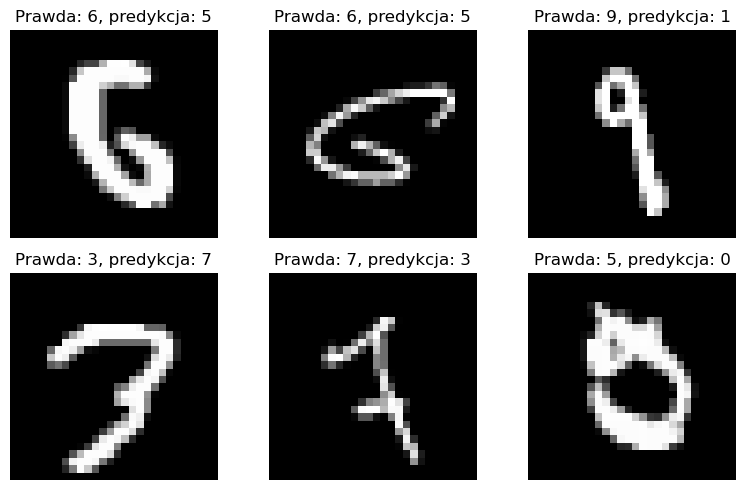

In [12]:
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)
wrong_indices = np.where(y_true_arr != y_pred_arr)[0]

fig, axs = plt.subplots(2, 3, figsize=(8, 5))
for ax in axs.flat:
    idx = np.random.choice(wrong_indices)
    img, _ = test_data[idx]
    ax.imshow(img[0], cmap="gray")
    ax.set_title(f"Prawda: {y_true_arr[idx]}, predykcja: {y_pred_arr[idx]}")
    ax.axis("off")
plt.tight_layout();

Większość błędnie sklasyfikowanych przykładów to cyfry zapisane w sposób nietypowy lub niejednoznaczny — dla wielu z nich i człowiek miałby kłopot z jednoznacznym odczytem.

## Podsumowanie

Sieci konwolucyjne adresują dwa fundamentalne problemy MLP na obrazach: liczbę parametrów (przez współdzielenie wag w filtrze) i brak niezmienniczości translacyjnej (przez ekwiwariancję konwolucji i niezmienniczość poolingu). Architektura CNN buduje hierarchię cech: pierwsze warstwy wykrywają proste wzorce lokalne (krawędzie, kąty), kolejne — bardziej złożone (tekstury, fragmenty obiektów), a pole recepcyjne rośnie wraz z głębokością, pozwalając wyższym warstwom „widzieć" coraz większe fragmenty obrazu.

LeNet-5 — sieć z 1998 roku — osiąga ~99% dokładności na MNIST z architekturą, która w całości mieści się w głowie. W kolejnym wykładzie zobaczymy, jak skalować ten pomysł do znacznie większych obrazów i znacznie głębszych sieci za pomocą **transfer learningu**: zamiast trenować CNN od zera, wykorzystamy sieci pretrenowane na ImageNet i dostroimy je do naszego zadania.